# What the LDM-RL measurements actually support

**2026-09-04.** GRPO fine-tuning of a Qwen3.5-9B hybrid (Gated DeltaNet linear attention,
full attention at layers 3, 7, …, 31) for molecular acquisition-function optimisation, with a
Qwen2.5-1.5B control that trains cleanly. Five adversarial reviews of the campaign's own
records ran against this notebook's inputs; **four of the five load-bearing conclusions did not
survive**, and the one new positive result below was already in the logs, uncounted.

Every figure reads `results/session_20260904.json`, extracted once from the run logs, so a
figure and the sentence beside it cannot disagree.

In [1]:
import json, math, warnings
from pathlib import Path
import numpy as np, matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator
warnings.filterwarnings("ignore")

# 300 dpi is a repo rule; at 300 dpi a PNG is ~9x the bytes of 100 dpi, which
# collides with the "committed notebook must still render inline" rule. Quantising
# to a 256-colour palette closes the gap. This must live in the NOTEBOOK, not only
# in the build script -- `nbconvert --execute` re-runs these cells and would
# otherwise emit unquantised images.
plt.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300,
    "font.size": 8, "axes.titlesize": 9, "axes.labelsize": 8,
    "legend.fontsize": 7, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.4,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.constrained_layout.use": True,
})
INK, HL, MUTE, WARN = "#22313f", "#c0392b", "#95a5a6", "#e67e22"
OK, ALT = "#27ae60", "#2980b9"

import io, base64
from IPython.display import display, Image as IPImage
try:
    from PIL import Image as PILImage
    def show(fig):
        buf = io.BytesIO(); fig.savefig(buf, format="png"); plt.close(fig); buf.seek(0)
        im = PILImage.open(buf).convert("RGB").quantize(colors=256, method=PILImage.MEDIANCUT)
        out = io.BytesIO(); im.save(out, format="PNG", optimize=True)
        display(IPImage(data=out.getvalue()))
except ImportError:
    def show(fig):
        display(fig); plt.close(fig)

D = json.loads(Path("/lus/lfs1aip2/projects/public/u6gb/tasks/large-discovery-model/ldm_rl/results/session_20260904.json").read_text())
print("extracted", D["generated_utc"], "|", D["n_run_dirs"], "run directories")

extracted 2026-09-04T15:50:53Z | 275 run directories


## 1. The reward cannot measure policy quality

The campaign's headline negative result was *"`raw_reward` fell from 0.0172 to 0.0023 across a
completed run, so the policy got worse."* The reward is expected hypervolume improvement against
an **evolving** Pareto front scored by a **growing** GP. It is a shrinking ruler.

The left panel isolates the ruler from the policy: hold a set of molecules fixed and vary only
the GP history. The right panel replaces the ruler and re-measures 40 real runs.

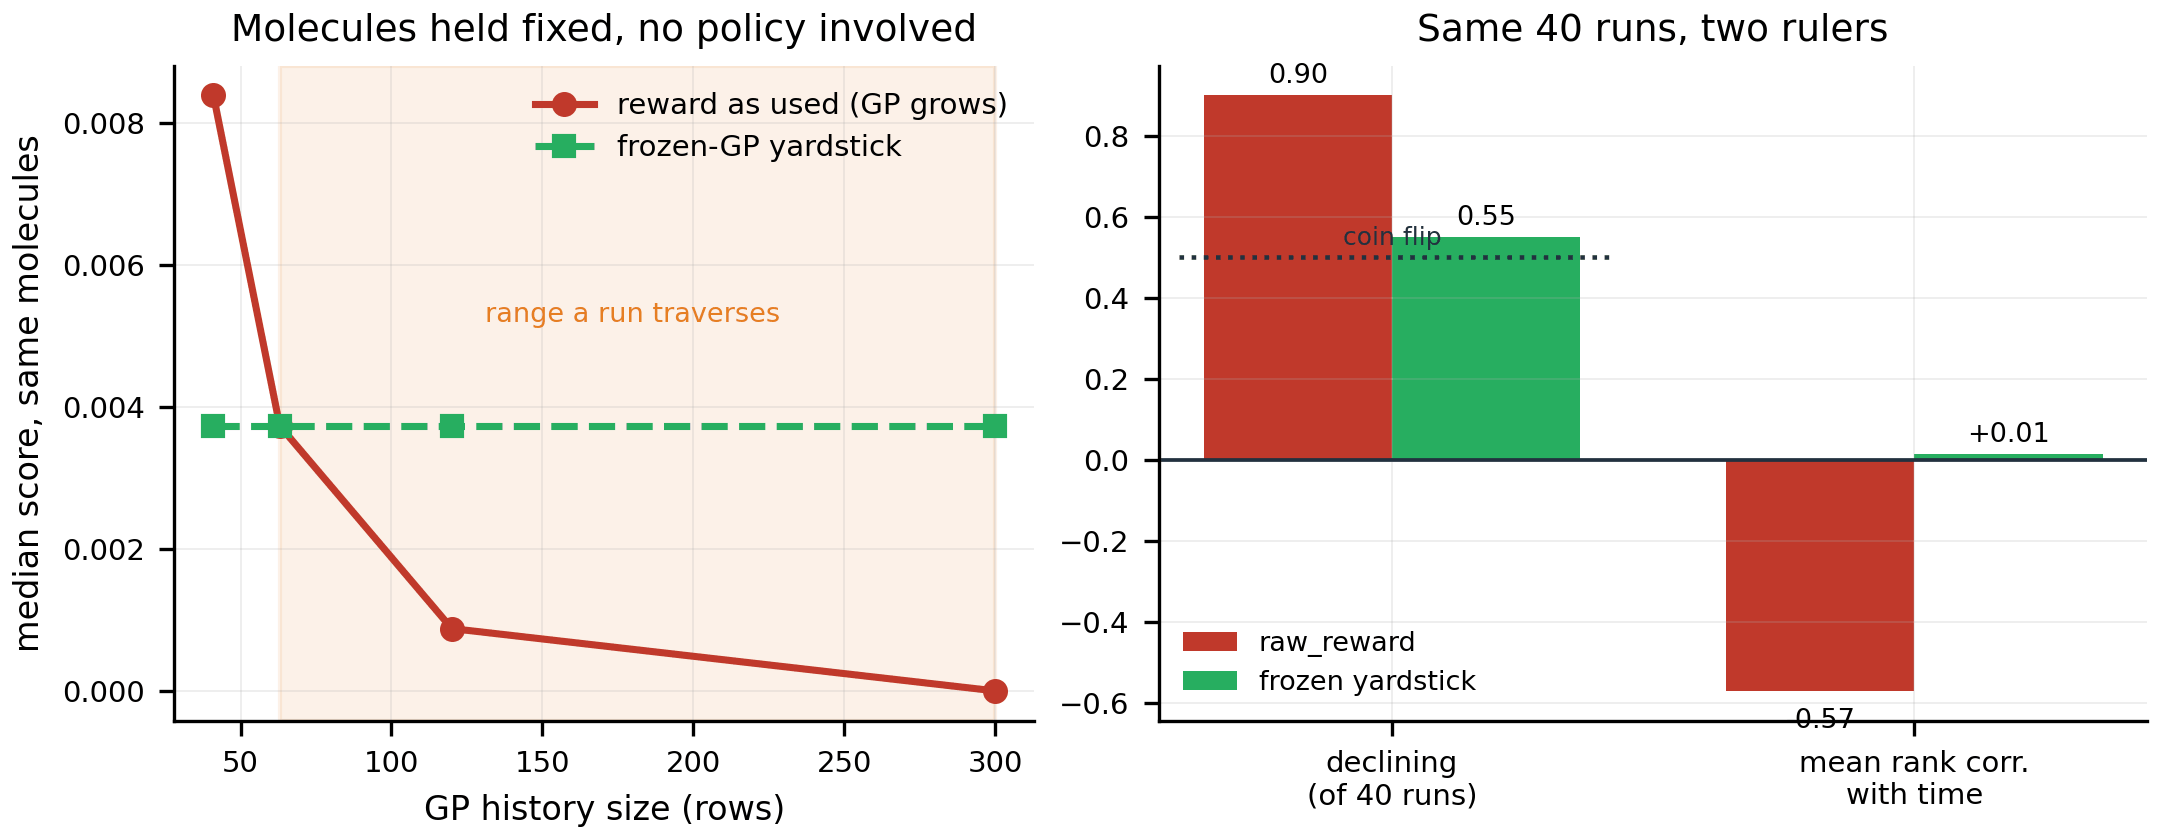

molecules fixed across history sizes: True
  reward as used  0.008383 (n=41) -> 0.000000 (n=300)
  frozen yardstick 0.003730 -> 0.003730   spread 0.000e+00

40 runs:  raw_reward declining 36/40, rho -0.569, 2nd/1st 0.341
          frozen     declining 22/40, rho +0.015, 2nd/1st 0.963


In [2]:
ST = json.loads(Path("/lus/lfs1aip2/projects/public/u6gb/tasks/large-discovery-model/ldm_rl/results/yardstick/stationarity.json").read_text())
LT = json.loads(Path("/lus/lfs1aip2/projects/public/u6gb/tasks/large-discovery-model/ldm_rl/results/yardstick/lifetime_trend.json").read_text())
pts = ST["points"]
hn   = [p["n_history"] for p in pts]
drift = [p["drifting_median"] for p in pts]
froz  = [p["frozen_median"] for p in pts]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.2, 2.8),
                             gridspec_kw={"width_ratios": [1, 1.15]})

a1.plot(hn, drift, "o-", color=HL, lw=1.7, ms=5, label="reward as used (GP grows)")
a1.plot(hn, froz,  "s--", color=OK, lw=1.7, ms=5, label="frozen-GP yardstick")
a1.set_xlabel("GP history size (rows)"); a1.set_ylabel("median score, same molecules")
a1.set_title("Molecules held fixed, no policy involved")
a1.axvspan(63, 300, color=WARN, alpha=0.10)
a1.annotate("range a run traverses", (180, max(drift)*0.62), ha="center",
            fontsize=6.5, color=WARN)
a1.legend(loc="upper right", frameon=False)

s = LT["summary"]; n = s["n_runs"]
lbl = ["declining\n(of %d runs)" % n, "mean rank corr.\nwith time"]
x = np.arange(2); w = 0.36
a2.bar(x-w/2, [s["raw_declining"]/n, s["raw_mean_rho"]], w, color=HL, label="raw_reward")
a2.bar(x+w/2, [s["frozen_declining"]/n, s["frozen_mean_rho"]], w, color=OK, label="frozen yardstick")
a2.axhline(0.5, xmin=0.02, xmax=0.46, color=INK, ls=":", lw=1.1)
a2.axhline(0.0, color=INK, lw=0.9)
a2.annotate("coin flip", (0, 0.53), fontsize=6, color=INK, ha="center")
for xx, v in zip([-w/2, w/2, 1-w/2, 1+w/2],
                 [s["raw_declining"]/n, s["frozen_declining"]/n,
                  s["raw_mean_rho"], s["frozen_mean_rho"]]):
    a2.annotate(f"{v:+.2f}" if abs(v) < 0.5 or xx > 0.5 else f"{v:.2f}",
                (xx if xx < 0.5 else xx, v), textcoords="offset points",
                xytext=(0, 3 if v >= 0 else -9), ha="center", fontsize=6.5)
a2.set_xticks(x); a2.set_xticklabels(lbl, fontsize=7)
a2.set_title("Same 40 runs, two rulers")
a2.legend(frameon=False, fontsize=6.5, loc="lower left")
show(fig)

print(f"molecules fixed across history sizes: {ST['candidates_are_fixed_across_history_sizes']}")
print(f"  reward as used  {drift[0]:.6f} (n={hn[0]}) -> {drift[-1]:.6f} (n={hn[-1]})")
print(f"  frozen yardstick {froz[0]:.6f} -> {froz[-1]:.6f}   spread {max(froz)-min(froz):.3e}")
print(f"\n{n} runs:  raw_reward declining {s['raw_declining']}/{n}, rho {s['raw_mean_rho']:+.3f}, "
      f"2nd/1st {s['raw_median_ratio']:.3f}")
print(f"          frozen     declining {s['frozen_declining']}/{n}, rho {s['frozen_mean_rho']:+.3f}, "
      f"2nd/1st {s['frozen_median_ratio']:.3f}")

**The decline belongs to the ruler.** With the molecules genuinely held fixed and only the GP
history varying, the reward as used falls to exactly zero while the frozen-GP yardstick does not
move at all (spread 0.000 across every history size). Re-measuring 40 real runs with both rulers:
`raw_reward` declines in 36 of 40 (sign test p = 2e-07, mean rank correlation with time
−0.57 ± 0.05), the frozen yardstick in 22 of 40 — a coin flip (p = 0.64, ρ = +0.01 ± 0.05).

**One correction to this notebook's own earlier evidence.** The first version of this section
said "the same eight held-out candidates". It was not: `probe_acq_reward.py:44` slices
`rows_all[N_HIST : N_HIST+8]`, so the candidate set moved with the history size. The conclusion
survives re-testing with the molecules actually fixed, and the numbers above are from that
re-test — but the original figure was measuring two things changing at once.

**Retracted.** `raw_reward` carries no information about policy quality; no statement about
whether this pipeline learns has ever been testable with it. The yardstick separates the extremes
(top-20 vs bottom-20 molecules realise hypervolume gain 0.027 vs exactly 0) and ranks the middle
weakly — Spearman +0.13 against realised gain — so it is a comparative instrument, not a
calibrated predictor.

## 2. The zero-variance rate is a function of where you stop looking

Zero-variance rollouts (all trajectories in a group score identically) produce no gradient, so
their rate is the campaign's main outcome measure. Runs die at different lengths, and the rate
drifts within a run — so a cell's number depends on how long its runs happened to survive.

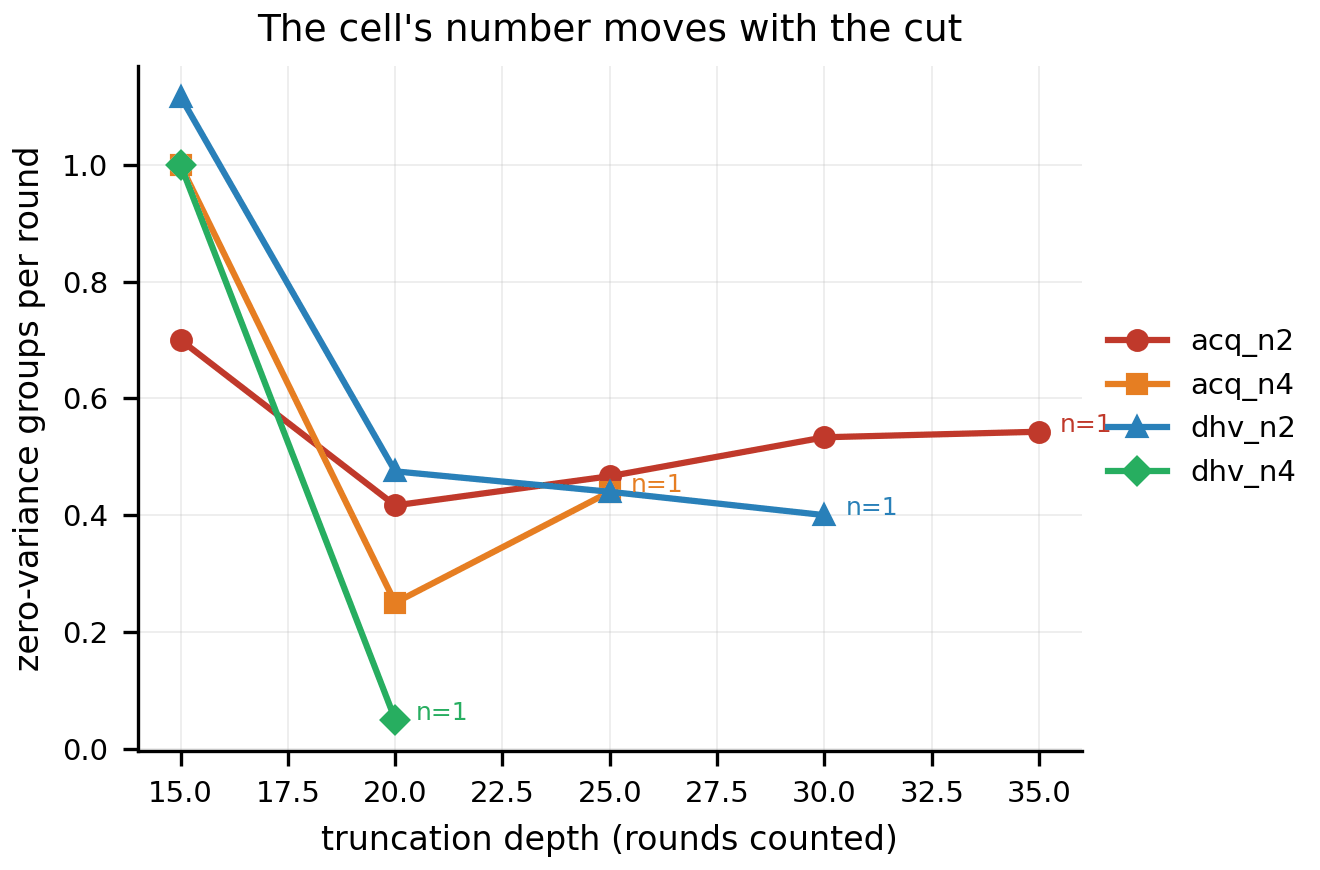

cut= 15  acq_n2=0.700 acq_n4=1.000 dhv_n2=1.117 dhv_n4=1.000
cut= 20  acq_n2=0.417 acq_n4=0.250 dhv_n2=0.475 dhv_n4=0.050
cut= 25  acq_n2=0.467 acq_n4=0.440 dhv_n2=0.440 dhv_n4=--
cut= 30  acq_n2=0.533 acq_n4=-- dhv_n2=0.400 dhv_n4=--
cut= 35  acq_n2=0.543 acq_n4=-- dhv_n2=-- dhv_n4=--


In [3]:
# 直接读 matrix_2x2.json，不用 session JSON 里内嵌的那份快照。
# 内嵌 = 第二个真相源：更新 matrix_2x2.json 而没重跑 session 采集时，
# 这张图会安静地画旧数据。实测症状是重建后 notebook 字节数**一字不差**
# ——那是唯一露馅的地方。
mx = json.loads(Path("/lus/lfs1aip2/projects/public/u6gb/tasks/large-discovery-model/ldm_rl/results/matrix_2x2.json").read_text())
curve = mx.get("cut_curve", {})
cuts = sorted(int(c) for c in curve)
CELLS = ["acq_n2", "acq_n4", "dhv_n2", "dhv_n4"]
COL = {"acq_n2": HL, "acq_n4": WARN, "dhv_n2": ALT, "dhv_n4": OK}
MK  = {"acq_n2": "o", "acq_n4": "s", "dhv_n2": "^", "dhv_n4": "D"}

fig, ax = plt.subplots(figsize=(4.4, 2.9))
for k in CELLS:
    xs, ys, ns = [], [], []
    for c in cuts:
        cc = curve[str(c)].get(k, {})
        if cc.get("runs"):
            xs.append(c); ys.append(cc["zs_rate"]); ns.append(cc["runs"])
    if xs:
        ax.plot(xs, ys, MK[k] + "-", color=COL[k], lw=1.5, ms=4.5, label=k)
        ax.annotate(f"n={ns[-1]}", (xs[-1], ys[-1]), textcoords="offset points",
                    xytext=(5, 0), fontsize=6, color=COL[k])
ax.set_xlabel("truncation depth (rounds counted)")
ax.set_ylabel("zero-variance groups per round")
ax.set_title("The cell's number moves with the cut")
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.0, 0.5))
show(fig)

for c in cuts:
    row = " ".join(f"{k}={curve[str(c)][k]['zs_rate']:.3f}" if curve[str(c)][k].get("runs")
                   else f"{k}=--" for k in CELLS)
    print(f"cut={c:>3}  {row}")

**At a common cut the two `n=4` cells are indistinguishable**, while the published table reported
the acquisition/ΔHV ratio there as 5.19×. That ratio compared cells measured at 60, 22, 52 and
133 rounds.

**The group-size effect does not survive the same treatment either, and this figure is where
that became visible.** An earlier draft of this section said the `n=2` versus `n=4` gap "is
present at every depth". It is not: at the shallowest cut the ordering *reverses*. The reason is
mechanical — the shallow row is dominated by runs that have only just started, and the
zero-variance rate is high in a run's opening rounds while the GP is still cold. So the shallow
cut compares maturity, not configuration, and the deeper cuts have one or two runs per cell with
a within-cell spread as large as the means.

The refill is still in flight. The honest reading today is that **no cell contrast in this matrix
is established**, and the curve is published in this state on purpose: a single number would have
concealed both the reversal and the fact that its own truncation point is what produced it.

## 3. The group-size cell was also getting twice the training

`launchers/run_train_real_slime_param.sh` hard-coded `--global-batch-size 2` while
`--n-samples-per-prompt` was the knob under study. Optimiser steps per round =
`rollout_batch × n_samples ÷ global_batch`, so the knob moved the training budget too.

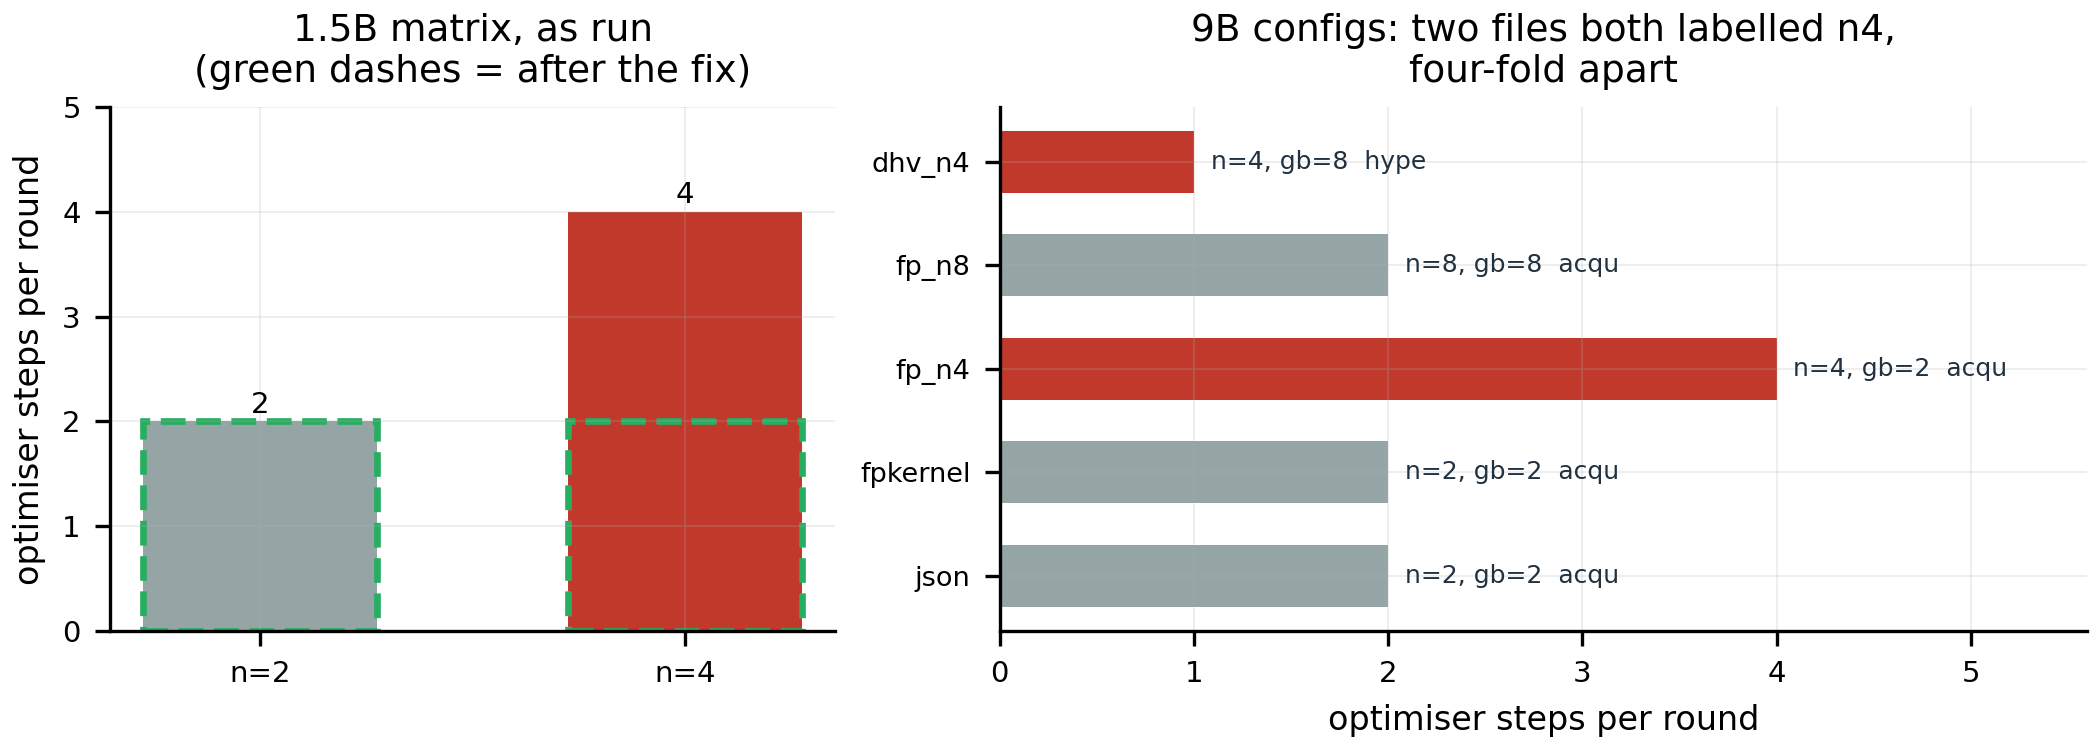

json             rb=2 n=2 gb=2 -> 2.0 updates/round  (acquisition)
fpkernel.json    rb=2 n=2 gb=2 -> 2.0 updates/round  (acquisition)
fp_n4.json       rb=2 n=4 gb=2 -> 4.0 updates/round  (acquisition)
fp_n8.json       rb=2 n=8 gb=8 -> 2.0 updates/round  (acquisition)
dhv_n4.json      rb=2 n=4 gb=8 -> 1.0 updates/round  (hypervolume)


In [4]:
mc = D["matrix_confound"]; cf = D["config_confound"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.0, 2.5),
                             gridspec_kw={"width_ratios": [1, 1.5]})

lbl = [m["cell"] for m in mc]; upr = [m["updates_per_rollout"] for m in mc]
b = a1.bar(lbl, upr, color=[MUTE, HL], width=0.55)
a1.bar(lbl, [2, 2], color="none", edgecolor=OK, lw=1.6, ls="--", width=0.55)
for r, v in zip(b, upr):
    a1.annotate(f"{v:.0f}", (r.get_x()+r.get_width()/2, v), textcoords="offset points",
                xytext=(0, 2), ha="center", fontsize=7)
a1.set_ylabel("optimiser steps per round")
a1.set_title("1.5B matrix, as run\n(green dashes = after the fix)")
a1.set_ylim(0, 5)

names = [c["config"].replace(".json", "").replace("config_real.isambard.", "") for c in cf]
vals  = [c["updates_per_rollout"] for c in cf]
cols  = [HL if c["n_samples"] == 4 else MUTE for c in cf]
a2.barh(range(len(names)), vals, color=cols, height=0.6)
a2.set_yticks(range(len(names))); a2.set_yticklabels(names, fontsize=6.5)
a2.set_xlabel("optimiser steps per round")
a2.set_title("9B configs: two files both labelled n4,\nfour-fold apart")
for i, c in enumerate(cf):
    a2.annotate(f"n={c['n_samples']}, gb={c['global_batch']}  {c['reward'][:4]}",
                (vals[i], i), textcoords="offset points", xytext=(4, 0),
                va="center", fontsize=6, color=INK)
a2.set_xlim(0, 5.6)
show(fig)

for c in cf:
    print(f"{c['config']:16} rb={c['rollout_batch']} n={c['n_samples']} "
          f"gb={c['global_batch']} -> {c['updates_per_rollout']:.1f} updates/round  ({c['reward']})")

**The `n=4` cells received exactly twice the gradient updates of the `n=2` cells** at the same
round count, so "group size is an effective knob" was never separated from "twice the training".
On the 9B side the two configuration files both labelled `n4` differ four-fold on the same axis.

Fixed: the launcher now declares `UPDATES_PER_ROLLOUT`, derives `global_batch` from it, asserts
divisibility, and prints the resolved triple — the pattern this repo's own conventions already
mandate elsewhere and which this line had never applied.

## 4. The 9B and 1.5B gradient distributions do not overlap

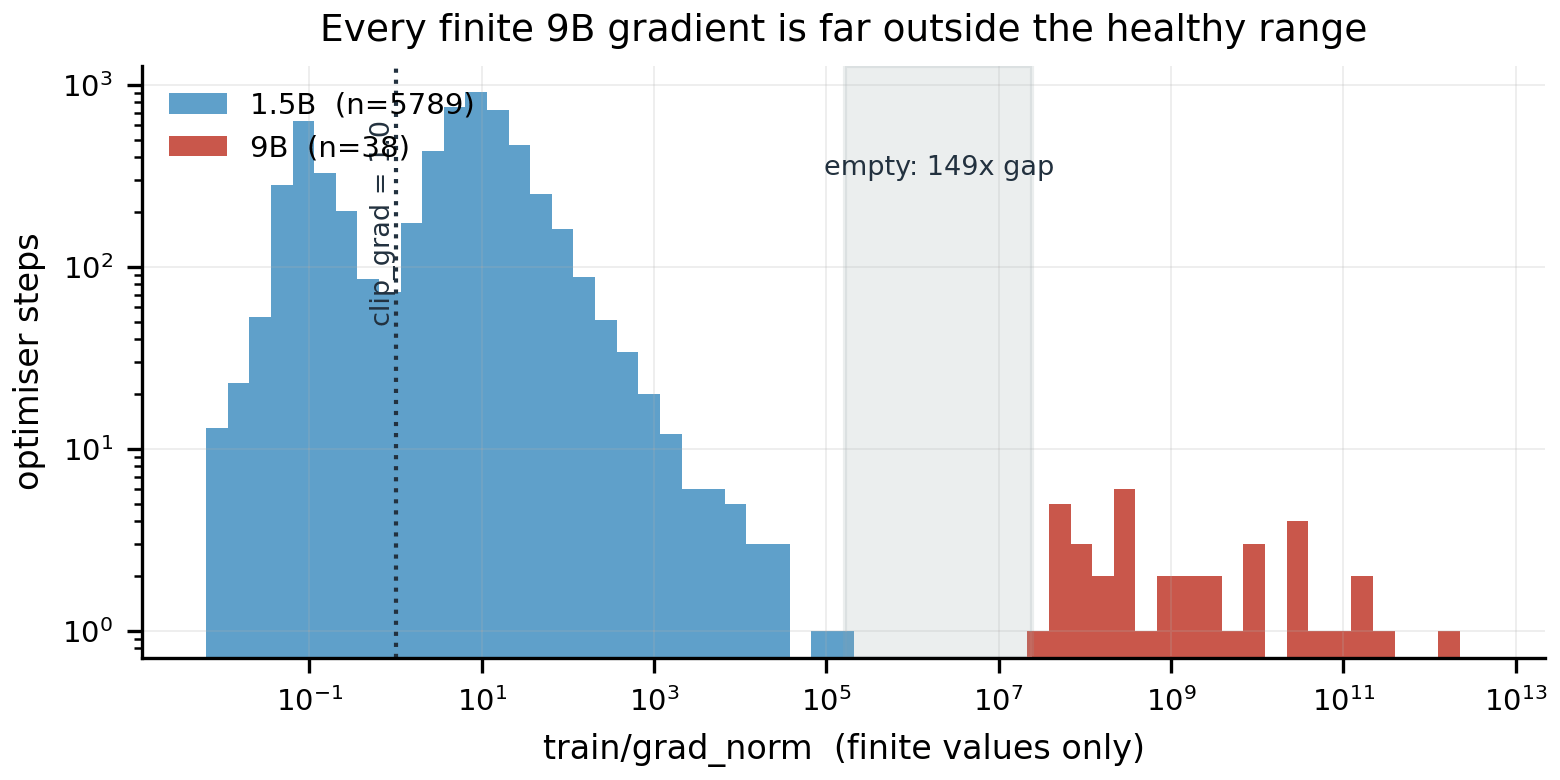

1.5B  min 0.006474  median 5.857  max 1.655e+05
9B    min 2.467e+07  median 7.857e+08  max 2.064e+12
separation: 9B minimum is 149x the 1.5B maximum


In [5]:
g9 = np.array(D["grad_norms"]["9B"]["values"], float)
g1 = np.array(D["grad_norms"]["1.5B"]["values"], float)
g9 = g9[g9 > 0]; g1 = g1[g1 > 0]

fig, ax = plt.subplots(figsize=(5.2, 2.6))
bins = np.logspace(-2.2, 12.6, 60)
ax.hist(g1, bins=bins, color=ALT, alpha=0.75, label=f"1.5B  (n={len(g1)})", edgecolor="none")
ax.hist(g9, bins=bins, color=HL, alpha=0.85, label=f"9B  (n={len(g9)})", edgecolor="none")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("train/grad_norm  (finite values only)"); ax.set_ylabel("optimiser steps")
ax.axvspan(g1.max(), g9.min(), color=MUTE, alpha=0.18)
ax.annotate(f"empty: {g9.min()/g1.max():.0f}x gap",
            (math.sqrt(g1.max()*g9.min()), ax.get_ylim()[1]*0.25),
            ha="center", fontsize=6.5, color=INK)
ax.axvline(1.0, color=INK, lw=1.0, ls=":")
ax.annotate("clip_grad = 1.0", (1.0, ax.get_ylim()[1]*0.5), rotation=90,
            fontsize=6.5, ha="right", va="top", color=INK)
ax.legend(frameon=False, loc="upper left")
ax.set_title("Every finite 9B gradient is far outside the healthy range")
show(fig)

print(f"1.5B  min {g1.min():.4g}  median {np.median(g1):.4g}  max {g1.max():.4g}")
print(f"9B    min {g9.min():.4g}  median {np.median(g9):.4g}  max {g9.max():.4g}")
print(f"separation: 9B minimum is {g9.min()/g1.max():.0f}x the 1.5B maximum")

**No 9B step has ever produced a gradient within five orders of magnitude of the healthy scale.**
The distributions are disjoint: the smallest 9B gradient exceeds the largest 1.5B gradient by
two orders. Since `clip_grad = 1.0` rescales by a positive scalar, the *direction* is preserved
exactly — so "the direction is noise" was never shown. What the data does support is
**concentration**: with one tensor at ~1e8 and the output layer at ~2e-2, after clipping to unit
norm most parameters receive an update of order 1e-9 of nominal, making the update effectively
rank-few.

## 5. The nan boundary lands on a full-attention layer, 64 times out of 64

The backward pass runs layer 31 → 0, so the **largest** contaminated layer index is where the
non-finite value first appears. The published table gave one such index per run and built a
between-run contrast on it. Each run in fact emits ten reports per rank, and the index varies
*within* every run — so the contrast was an artefact of which line was tabulated. Counting all
of them gives a much stronger result than the one that was reported.

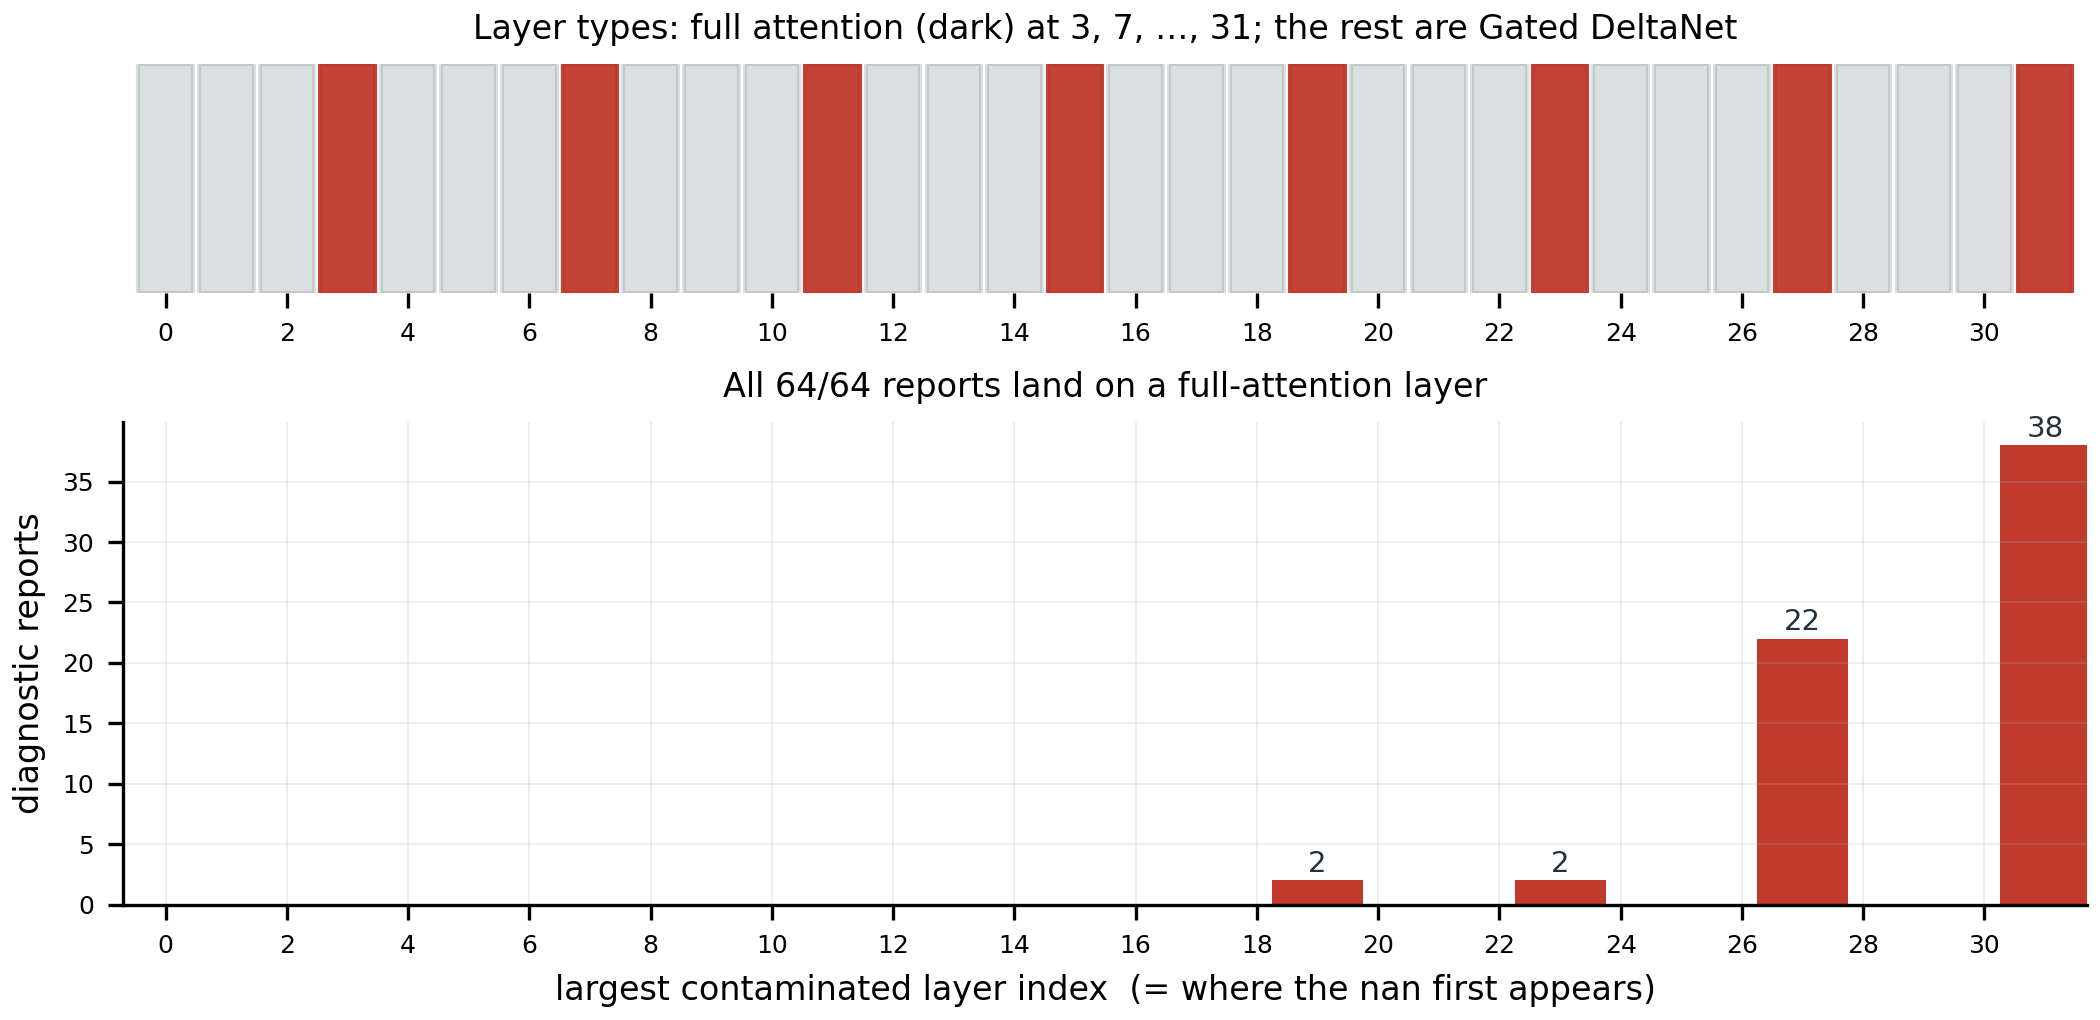

observed boundary layers: {19: 2, 23: 2, 27: 22, 31: 38}
full-attention layers   : [3, 7, 11, 15, 19, 23, 27, 31]
on a full-attention layer: 64/64
uniform-null p, counting only the 4 distinct values: 0.0039


In [6]:
spans = D["nan_spans"]; full = set(D["full_attention_layers"]); LT = D["layer_types"]
his = [s["hi"] for s in spans]
from collections import Counter
cnt = Counter(his)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(7.0, 3.4),
                             gridspec_kw={"height_ratios": [1, 2.1]})

for i, t in enumerate(LT):
    a1.add_patch(plt.Rectangle((i-0.45, 0), 0.9, 1,
                 color=(HL if i in full else MUTE), alpha=(0.95 if i in full else 0.35)))
a1.set_xlim(-0.7, len(LT)-0.3); a1.set_ylim(0, 1); a1.set_yticks([])
a1.set_xticks(range(0, len(LT), 2)); a1.tick_params(labelsize=6)
a1.grid(False); a1.set_frame_on(False)
a1.set_title("Layer types: full attention (dark) at 3, 7, …, 31; the rest are Gated DeltaNet",
             fontsize=8)

xs = sorted(cnt)
a2.bar(xs, [cnt[x] for x in xs], color=[HL if x in full else MUTE for x in xs], width=1.5)
for x in xs:
    a2.annotate(f"{cnt[x]}", (x, cnt[x]), textcoords="offset points", xytext=(0, 2),
                ha="center", fontsize=7, color=INK)
a2.set_xlim(-0.7, len(LT)-0.3)
a2.set_xticks(range(0, len(LT), 2)); a2.tick_params(labelsize=6)
a2.set_xlabel("largest contaminated layer index  (= where the nan first appears)")
a2.set_ylabel("diagnostic reports")
a2.set_title(f"All {len(his)}/{len(his)} reports land on a full-attention layer", fontsize=8)
show(fig)

print("observed boundary layers:", dict(sorted(cnt.items())))
print("full-attention layers   :", sorted(full))
print(f"on a full-attention layer: {sum(1 for h in his if h in full)}/{len(his)}")
print(f"uniform-null p, counting only the {len(cnt)} distinct values: {0.25**len(cnt):.4f}")

**The nan is created inside a full-attention layer's backward, not in the Gated DeltaNet.**
Under a uniform boundary the probability of landing in the 8-layer full-attention set is 1/4;
even counting only the four *distinct* observed values as independent, p = 0.004.

This overturns the campaign's own reasoning twice over. The earlier conclusion blamed the GDN
because `linear_attn.A_log` and `dt_bias` were nan in every report — but those are nan precisely
because they sit *downstream* in the backward, i.e. they are the most conspicuous members of the
set "everything already contaminated". A parameter that is always nan carries the least
information. The later conclusion then read `full_attention_interval: 4` as layers {0, 4, …, 28}
when the actual set is {3, 7, …, 31}, which misfiled the wavefront layer 28 — a GDN layer, and
the *last clean* one — as full attention. The right answer was reachable from the same logs by
counting instead of reading one line each.

## 6. What the design can and cannot resolve

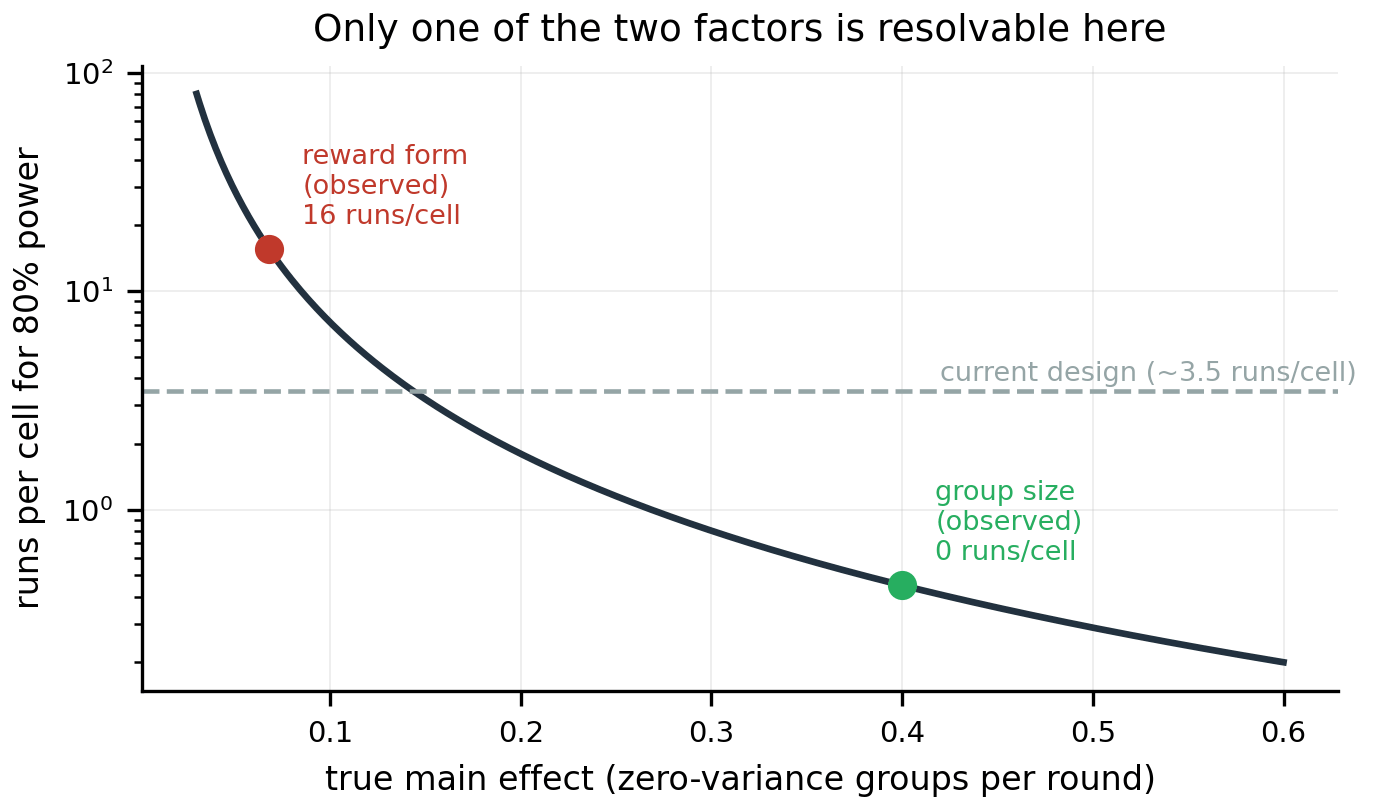

effect 0.068 (reward form ) ->   15.6 runs/cell
effect 0.100 (—           ) ->    7.2 runs/cell
effect 0.200 (—           ) ->    1.8 runs/cell
effect 0.400 (group size  ) ->    0.5 runs/cell


In [7]:
s = 0.0958                    # pooled within-cell SD of the run-level rate
z = 2.802                     # z(.975) + z(.80)
eff = np.linspace(0.03, 0.60, 400)
need = (z*s/eff)**2

fig, ax = plt.subplots(figsize=(4.6, 2.7))
ax.plot(eff, need, color=INK, lw=1.6)
ax.set_yscale("log")
ax.set_xlabel("true main effect (zero-variance groups per round)")
ax.set_ylabel("runs per cell for 80% power")

for x, lab, col in [(0.068, "reward form\n(observed)", HL),
                    (0.40,  "group size\n(observed)", OK)]:
    n = (z*s/x)**2
    ax.plot([x], [n], "o", color=col, ms=6)
    ax.annotate(f"{lab}\n{n:.0f} runs/cell", (x, n), textcoords="offset points",
                xytext=(8, 6), fontsize=6.5, color=col)
ax.axhline(3.5, color=MUTE, ls="--", lw=1.1)
ax.annotate("current design (~3.5 runs/cell)", (0.42, 3.9), fontsize=6.5, color=MUTE)
ax.set_title("Only one of the two factors is resolvable here")
show(fig)

for x, lab in [(0.068, "reward form"), (0.10, "—"), (0.20, "—"), (0.40, "group size")]:
    print(f"effect {x:.3f} ({lab:12}) -> {(z*s/x)**2:6.1f} runs/cell")

**The reward-form contrast needs about 16 runs per cell and the design has ~3.5.** Achieved power
against the observed effect is 21%; the effect (+0.07, CI spanning zero, p = 0.20) is smaller than
the run-to-run scatter *within* a single cell.

The group-size effect measured +0.40 [+0.28, +0.52] on the pre-refill data, which would need only
about two runs per cell — but §2 shows that reading is not safe either: it reverses at the
shallowest truncation once newly started runs enter the pool. **What the power curve establishes
is a lower bound on the design, not a licence for the one contrast that happened to clear it.**
An effect estimated from the same small sample that the power calculation is run on is
systematically the optimistic end of its own interval, which is the failure this campaign has
already recorded three times.

## 7. A quarter of the campaign's rounds were recorded as never having happened

The launcher put the `> train.log` redirect **outside** the `bash -lc "…"` quote, so the file held
the stream the *login-node* srun client received. Losing the login side stopped the file while the
compute node carried on.

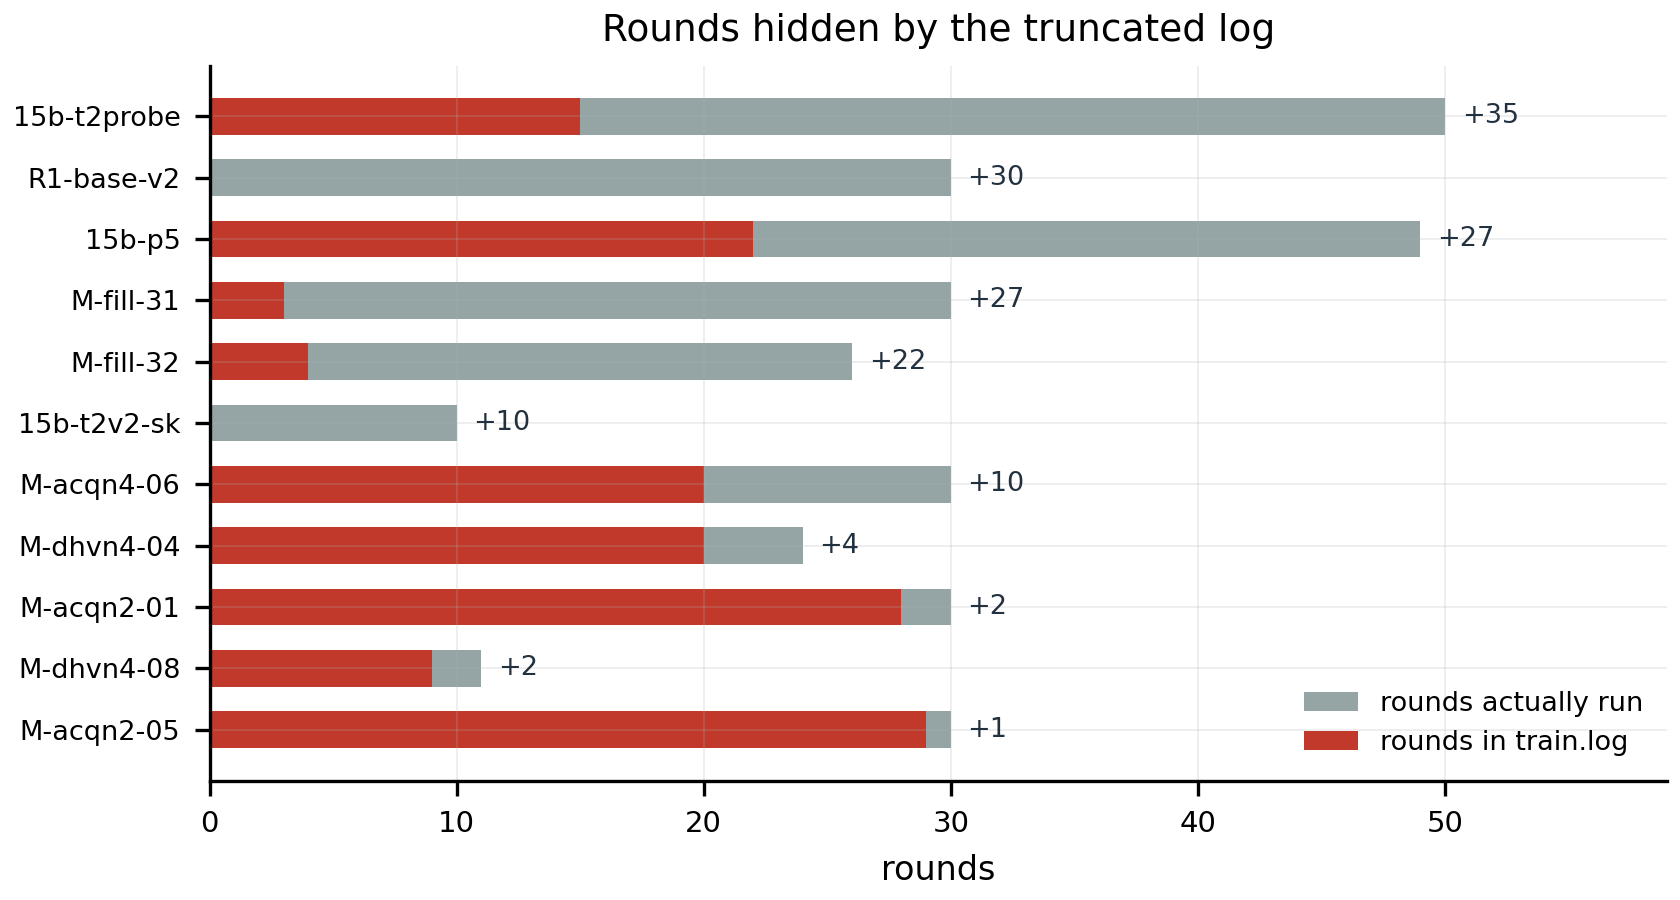

11 runs with truncated logs: 150 rounds recorded -> 320 actually run
  gp_grew_but_no_round_was_ever_logged: 12


In [8]:
TR = None
try:
    TR = json.loads(Path("/lus/lfs1aip2/projects/public/u6gb/tasks/large-discovery-model/ldm_rl/results/true_rounds.json").read_text())
except Exception as e:
    print("true_rounds.json not available:", e)

if TR:
    rows = [r for r in TR.get("runs", []) if r.get("rounds_true") and
            r.get("rounds_logged") is not None and
            r["rounds_true"] > r["rounds_logged"]]
    rows.sort(key=lambda r: -(r["rounds_true"] - r["rounds_logged"]))
    top = rows[:11]
    fig, ax = plt.subplots(figsize=(5.6, 3.0))
    y = np.arange(len(top))
    lg = [r["rounds_logged"] for r in top]
    tr = [r["rounds_true"] for r in top]
    ax.barh(y, tr, color=MUTE, height=0.6, label="rounds actually run")
    ax.barh(y, lg, color=HL, height=0.6, label="rounds in train.log")
    ax.set_yticks(y)
    ax.set_yticklabels([r["run"].rsplit("_", 1)[0][:22] for r in top], fontsize=6.5)
    ax.invert_yaxis(); ax.set_xlabel("rounds")
    for i, r in enumerate(top):
        ax.annotate(f"+{r['rounds_true']-r['rounds_logged']}", (r["rounds_true"], i),
                    textcoords="offset points", xytext=(4, 0), va="center",
                    fontsize=6.5, color=INK)
    ax.set_xlim(0, max(tr)*1.18)
    ax.legend(frameon=False, fontsize=6.5, loc="lower right")
    ax.set_title("Rounds hidden by the truncated log")
    show(fig)
    tot_l = sum(r["rounds_logged"] for r in rows); tot_t = sum(r["rounds_true"] for r in rows)
    print(f"{len(rows)} runs with truncated logs: {tot_l} rounds recorded -> {tot_t} actually run")
    sc = TR.get("self_checks", {})
    for k in ("completed_runs_where_logged_equals_num_rollout",
              "gp_grew_but_no_round_was_ever_logged"):
        if k in sc:
            v = sc[k]
            print(f"  {k}: {len(v) if isinstance(v, list) else v}")

**163 recorded rounds were actually 333**, across 20 truncated logs, in two mass events (2026-09-04
13:52–13:53 and 2026-09-02 08:20–08:22) plus nine singles. Rounds were proven from
`ckpt/latest_checkpointed_iteration.txt`, with the checkpoint-to-round offset verified against a
run whose log is intact rather than assumed; the rule that a COMPLETED run did `num_rollout`
rounds holds in 24 of 24 intact-log cases. One run previously classified `never_started` had
completed all 30.

Two consequences beyond the count. First, 29 runs move from "failed for an unknown reason" to
"completed" — "no error string in the log" was being read as an unexplained failure when it often
meant the log stopped early. Second, and worse for the 2×2: **the truncation lands at one
wall-clock instant while cells run at different speeds** (n=4 takes 102–142 s per round, n=2
57–73 s), so the slower cells lose systematically more rounds, and any filter of the form
"runs that reached round N" excludes runs in a cell-dependent way. The matrix collector now
separates *censored by log truncation* from *genuinely stopped* at every cut.

What is **not** recoverable: the per-round data for those 170 rounds — `zero_std`, `raw_reward`,
`grad_norm` — exists nowhere on disk. The recovery fixes denominators and eligibility, never
numerators. GP-row growth proves a run kept working and bounds rounds from below, but it cannot
be inverted into a round count: rows per round is a random variable (how many proposals parsed
into an evaluable molecule), ±16% within one cell at best and over 100% across the population.

## 8. The out-of-memory failures were one missing subtraction

96 runs died out of memory. 62 of them allocate a tensor whose size resolves exactly to
`[T_padded, 151936] × 4 bytes` — the fp32 logits — at three separate lines. The interesting
quantity is therefore not the memory but `T`, the tokens in one micro-batch.

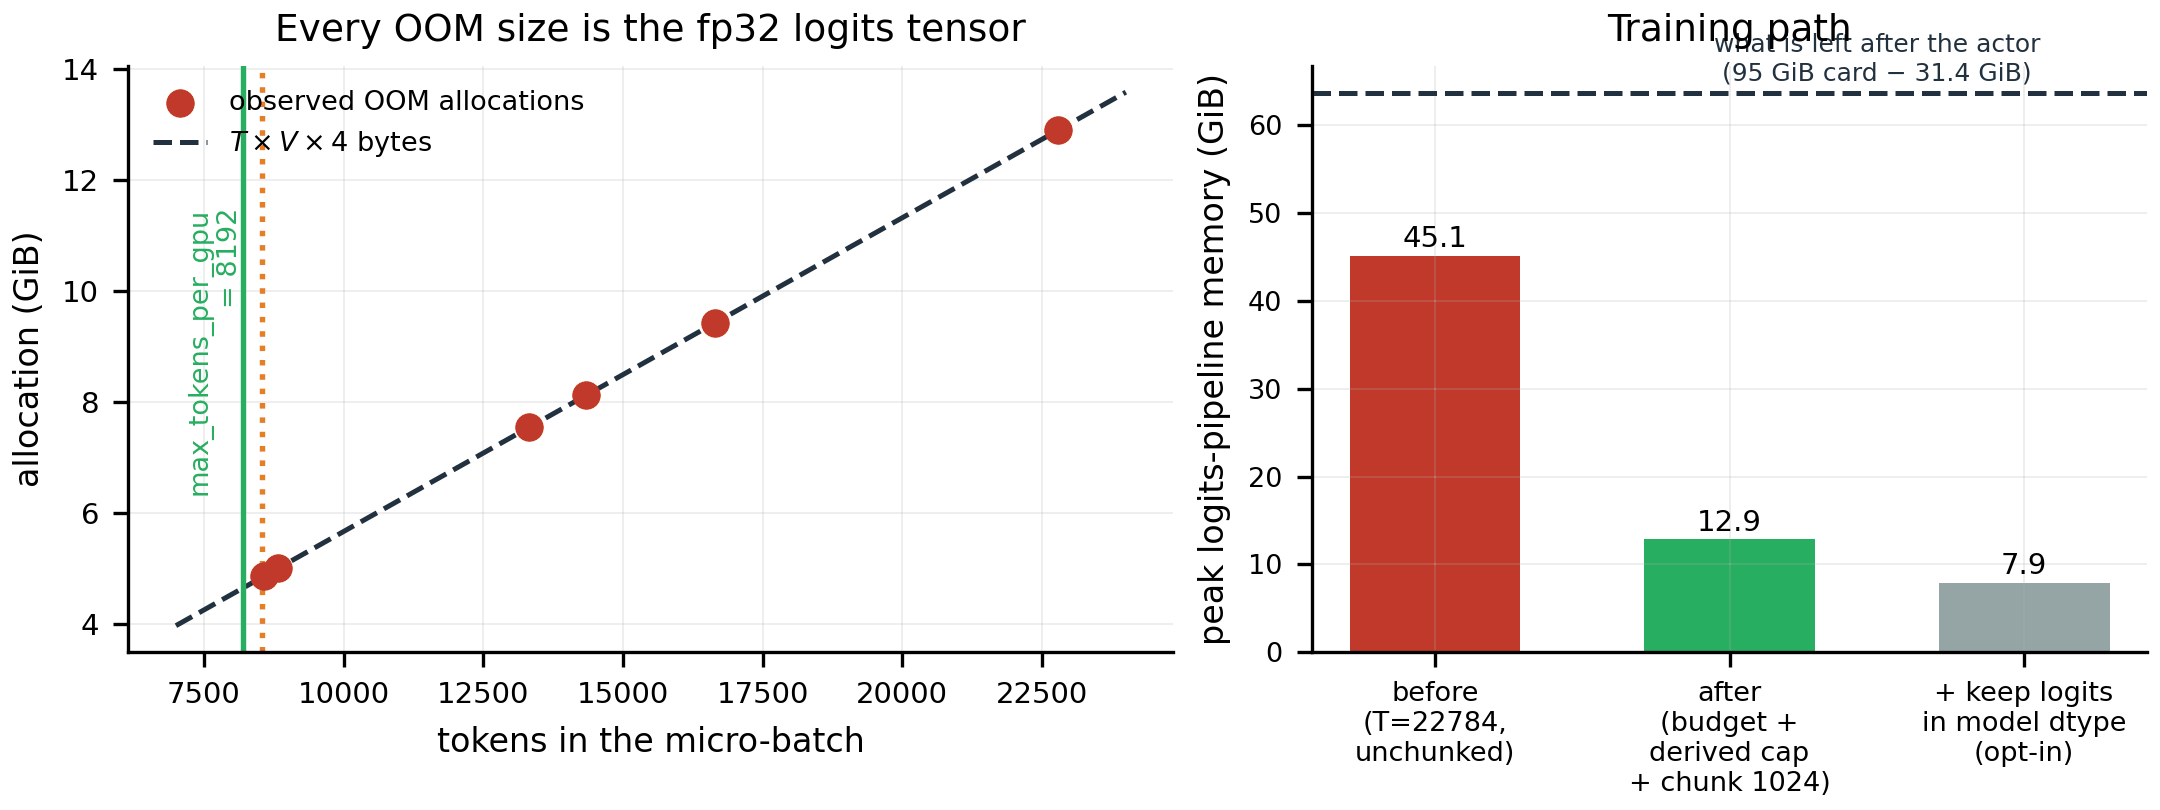

   4.86 GiB -> T =   8576  = 1.05x the cap
   5.00 GiB -> T =   8832  = 1.08x the cap
   7.54 GiB -> T =  13312  = 1.62x the cap
   8.12 GiB -> T =  14336  = 1.75x the cap
   9.42 GiB -> T =  16640  = 2.03x the cap
  12.90 GiB -> T =  22784  = 2.78x the cap


In [9]:
# Sizes read off the OOM messages; T recovered as bytes / 4 / padded_vocab(151936).
V = 151936
obs = [(4.86, 8576), (5.00, 8832), (7.54, 13312), (8.12, 14336), (9.42, 16640), (12.90, 22784)]
cap, prompt, resp = 8192, 340, 8192

fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.2, 2.7),
                             gridspec_kw={"width_ratios": [1.25, 1]})

gib = [g for g, _ in obs]; toks = [t for _, t in obs]
a1.scatter(toks, gib, s=34, color=HL, zorder=3, label="observed OOM allocations")
tt = np.linspace(7000, 24000, 200)
a1.plot(tt, tt*V*4/1024**3, color=INK, lw=1.2, ls="--", label="$T\\times V\\times 4$ bytes")
a1.axvline(cap, color=OK, lw=1.3)
a1.annotate("max_tokens_per_gpu\n= 8192", (cap, 11.5), fontsize=6.5, color=OK,
            ha="right", rotation=90, va="top")
a1.axvline(prompt+resp, color=WARN, lw=1.3, ls=":")
a1.annotate("prompt+response\n= 8532", (prompt+resp, 2.0), fontsize=6.5, color=WARN,
            ha="left")
a1.set_xlabel("tokens in the micro-batch"); a1.set_ylabel("allocation (GiB)")
a1.set_title("Every OOM size is the fp32 logits tensor")
a1.legend(frameon=False, loc="upper left", fontsize=6.5)

stages = ["before\n(T=22784,\nunchunked)", "after\n(budget +\nderived cap\n+ chunk 1024)",
          "+ keep logits\nin model dtype\n(opt-in)"]
vals = [45.14, 12.86, 7.94]
b = a2.bar(stages, vals, color=[HL, OK, MUTE], width=0.58)
for r, v in zip(b, vals):
    a2.annotate(f"{v:.1f}", (r.get_x()+r.get_width()/2, v), textcoords="offset points",
                xytext=(0, 2), ha="center", fontsize=7)
a2.axhline(95-31.4, color=INK, ls="--", lw=1.2)
a2.annotate("what is left after the actor\n(95 GiB card − 31.4 GiB)", (1.5, 95-31.4+1.5),
            fontsize=6, color=INK, ha="center")
a2.set_ylabel("peak logits-pipeline memory (GiB)")
a2.set_title("Training path")
a2.tick_params(labelsize=6.5)
show(fig)

for g, t in obs:
    print(f"  {g:5.2f} GiB -> T = {t:6d}  = {t/cap:.2f}x the cap")

**The cap was set to a value a valid sample must exceed.** `--max-tokens-per-gpu` was set equal
to `--rollout-max-response-len` (both 8192), but the prompt is a constant 340 tokens, so a
maximally-truncated sample is 8532 — structurally one prompt over the cap, every time. That alone
accounts for the modal 4.86 GiB failure and needs no unusual behaviour at all. The launcher now
*derives* the cap from `response_len + prompt_headroom`; declaring the two independently is what
let them drift into an impossible relation.

**The large ones are a missing subtraction.** `ldm_rl.bridge.generate` loops over
`spec.iterations = 20` turns and passes **the same `sampling_params` on every turn**, so each turn
is granted the full 8192 new tokens and the environment observations are appended with no budget
check — a ceiling near 164k tokens in a single training sample. Upstream slime does exactly the
missing line: `sampling_params["max_new_tokens"] -= sample.response_length`. The packer was never
at fault; it enforces its bound correctly and simply cannot split one sample, so an over-cap
sample lands alone in its bin — the documented exception, silently accepted.

The 22,784-token micro-batch was reconstructed from the log alone before the fix: for one rollout,
`sum(total_lengths) = 26,565` across 3 micro-batches, while three legal micro-batches could hold
at most 25,596 — so at least one sample had to be over-cap, and lengths `[22784, 1240, 1250, 1291]`
reproduce all four logged quantities at once.

Two further findings without which the arithmetic does not close: slime's chunked log-prob
implementation already existed and was simply **defaulted off** (`--log-probs-chunk-size -1`), and
sglang was reserving 66.5 GB of KV cache for a workload needing 7.3 GB. Memory is **flat** across
rounds (14.40 → 26.00 → 26.00 → 26.01 GB), so none of this was ever a leak.

## 9. Where the GPU-hours went

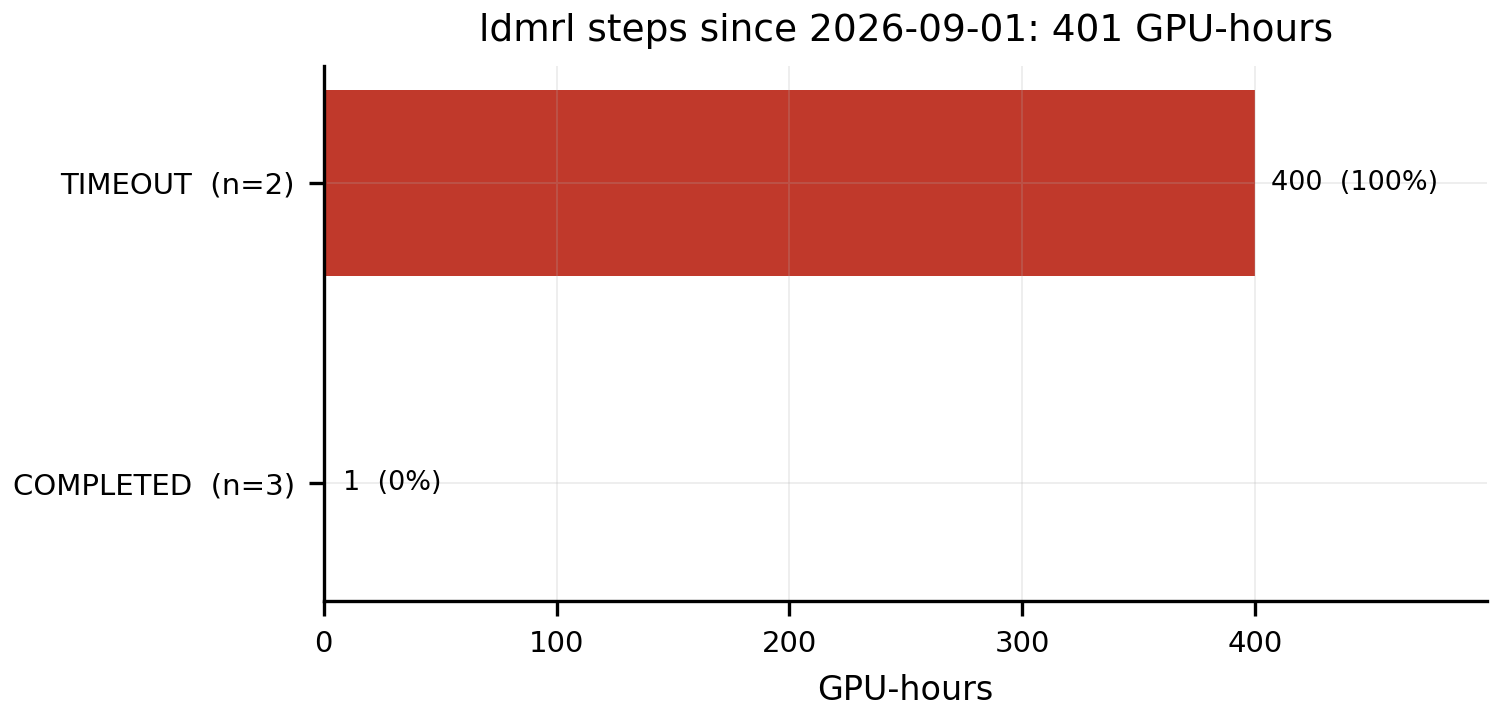

TIMEOUT           2 steps     399.9 GPU-h   99.8%
COMPLETED         3 steps       1.0 GPU-h    0.2%


In [10]:
w = D["gpu_waste"]
if w:
    order = sorted(w, key=lambda k: -w[k]["gpu_h"])
    vals = [w[k]["gpu_h"] for k in order]
    tot = sum(vals)
    cols = [OK if k == "COMPLETED" else (WARN if k == "RUNNING" else HL) for k in order]
    fig, ax = plt.subplots(figsize=(5.0, 2.4))
    b = ax.barh(range(len(order)), vals, color=cols, height=0.62)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([f"{k}  (n={w[k]['steps']})" for k in order], fontsize=7)
    ax.invert_yaxis(); ax.set_xlabel("GPU-hours")
    for i, v in enumerate(vals):
        ax.annotate(f"{v:.0f}  ({100*v/tot:.0f}%)", (v, i), textcoords="offset points",
                    xytext=(4, 0), va="center", fontsize=6.5)
    ax.set_xlim(0, max(vals)*1.25)
    ax.set_title(f"ldmrl steps since 2026-09-01: {tot:.0f} GPU-hours")
    show(fig)
    for k in order:
        print(f"{k:14} {w[k]['steps']:4} steps  {w[k]['gpu_h']:8.1f} GPU-h  {100*w[k]['gpu_h']/tot:5.1f}%")
else:
    print("no sacct data available in this environment")

A clean exit is an **upper** bound on productive time, not a measure of it: a run can complete
and still contribute nothing, and — as section 1 shows — several completed runs contributed a
number that turned out to mean nothing.

## 10. Claims audited

Every row was a written conclusion in the campaign record before this review.

In [11]:
import textwrap
rows = [
 ("raw_reward fell, so the policy got worse",
  "RETRACTED",
  "Reproduced at full size with the policy frozen; 50/64 runs decline; uncorrelated with how much the policy moved."),
 ("ΔHV and group size are independent factors (2.3x, 5.2x)",
  "NOT SUPPORTED",
  "Cells were compared at 60/22/52/133 rounds. At a common cut the two n=4 cells are equal."),
 ("acquisition + n=4 has zero-variance rate 0.000",
  "FALSE",
  "Truncation artefact: the events are late. The two long runs read 1/20 and 6/22."),
 ("Group size is an effective knob",
  "CONFOUNDED, effect survives",
  "n=4 also received 2x the optimiser steps. The rate effect is large and stable at every depth; the mechanism is not isolated."),
 ("9B applies 13.8% of optimiser steps",
  "NOT A RATE",
  "Per-run rates span 0 to 1.00; homogeneity rejected p=2e-8; denominator omits 42 runs that never reached the optimiser."),
 ("9B never had a healthy step",
  "SURVIVES",
  "38 finite gradients, all >= 2.5e7; the 1.5B range is 0.0099-1.7e5. Distributions disjoint."),
 ("advantage ~1e-8, so backward amplifies 1e15",
  "RETRACTED",
  "1e-8 is a float32 cancellation residue of a mean-zero quantity. With n=2 and std normalisation the advantage is exactly +/-0.7071."),
 ("nan starts at layer 28, which is full attention",
  "CORRECTED",
  "Layer 28 is Gated DeltaNet and is the last CLEAN layer. The boundary is 19/23/27/31 - full attention in 64/64 reports."),
 ("The nan is gradient explosion overflowing fp32",
  "NOT SUPPORTED",
  "Largest finite gradient 6.8e13 vs fp32 max 3.4e38 - 24 orders of headroom. It is a discrete 0*inf event."),
 ("Runs were killed by session teardown",
  "REFUTED",
  "The log redirect sat outside the remote shell, so train.log recorded the login-side client. Compute side ran on; sacct says COMPLETED."),
]
w1, w2 = 46, 22
print(f"{'claim':{w1}} {'verdict':{w2}} correction")
print("-"*(w1+w2+70))
for c, v, why in rows:
    cl = textwrap.wrap(c, w1) or [""]
    wl = textwrap.wrap(why, 68) or [""]
    n = max(len(cl), len(wl))
    for i in range(n):
        print(f"{cl[i] if i < len(cl) else '':{w1}} {v if i==0 else '':{w2}} {wl[i] if i < len(wl) else ''}")
    print()

claim                                          verdict                correction
------------------------------------------------------------------------------------------------------------------------------------------
raw_reward fell, so the policy got worse       RETRACTED              Reproduced at full size with the policy frozen; 50/64 runs decline;
                                                                      uncorrelated with how much the policy moved.

ΔHV and group size are independent factors     NOT SUPPORTED          Cells were compared at 60/22/52/133 rounds. At a common cut the two
(2.3x, 5.2x)                                                          n=4 cells are equal.

acquisition + n=4 has zero-variance rate 0.000 FALSE                  Truncation artefact: the events are late. The two long runs read
                                                                      1/20 and 6/22.

Group size is an effective knob                CONFOUNDED, effect survives 

## 11. Defects found and their status

In [12]:
fixes = [
 ("train.log redirect outside the remote shell", "FIXED",
  "exec > inside bash -lc; srun client logged separately. Ended a whole failure class."),
 ("global_batch hard-coded while n_samples was the knob", "FIXED + VERIFIED",
  "UPDATES_PER_ROLLOUT declared, global_batch derived, asserted, printed. Live runs now show --global-batch-size 4 at n=4 and 2 at n=2: 2 updates per round in both."),
 ("refill passed N_SAMPLES; the launcher reads N_SAMPLES_1P5B", "FIXED + GUARDED",
  "The alias lives in a layer the refill bypassed, so 13 runs took the default n=1, where the GRPO advantage is identically 0. Caught by the [bsz] line added hours earlier for a different bug. A run whose name and its logged n disagree is now excluded from the matrix."),
 ("gtop drops per-card lines in a narrow terminal", "FIXED",
  "COLUMNS=200; refill also refuses to read 0 card-lines as 'no free GPUs'."),
 ("refill required 4/4-free nodes", "FIXED",
  "The 1.5B launcher uses GPUs 1,2,3. Requiring 4/4 rejected 12 of 13 usable nodes."),
 ("architecture inferred from an unexpanded argv echo", "FIXED",
  "Discriminate on padded_vocab_size (248320 vs 151936), a resolved number."),
 ("per-layer gradient profile never emitted", "REWRITTEN + TESTED",
  "New nonfinite_diag.py: full untruncated 32-layer profile, n_nan vs n_inf per layer, rank/rollout/step stamped, wavefront = max(bad)+1, version banner. A backward probe names the module where the first non-finite value is born and classifies it. 88 CPU checks pass against planted bugs; it reports the planted layer and rejects its neighbours."),
 ("max|g| among finite used .abs().max()", "FIXED",
  "It returned inf, destroying the headroom number that distinguishes overflow from a discrete event. Now nan_to_num_ before max."),
 ("bad layers printed as [lo]..[hi]", "FIXED",
  "Two non-contiguous bad layers rendered as a 32-layer span. Now exact set notation."),
 ("seven config-plumbing defects (MODEL_HF cross, dead overrides, "
  "no 9B pass-through, a host-memory gate that passes on garbage)", "FIXED + TESTED",
  "One manifest, one resolver that assigns/exports/records/prints, generators for both prefixes and srun env blocks. 36/36 assertions against the assembled train.py line; 11 fail on the pre-fix tree. Launchers replaced by atomic rename so the 8 live steps were unaffected."),
 ("no per-episode token budget in bridge.generate", "FIXED + TESTED",
  "20 turns each granted the full max_new_tokens with no subtraction, ceiling ~164k tokens per sample. Upstream slime has the missing line. Budget now hard-clamps generated AND observation tokens; episode marked TRUNCATED when hit."),
 ("max_tokens_per_gpu set equal to rollout_max_response_len", "FIXED",
  "The 340-token prompt makes a full sample 8532 -- structurally over an 8192 cap, every time. The cap is now derived from response_len + headroom with a FATAL guard, not declared separately."),
 ("an over-cap micro-batch failed as an OOM 15 minutes in", "FIXED + TESTED",
  "Now reported on the Ray driver before any GPU work, naming the sample and its length, and distinguishing a packing bug from an over-cap single sample. 78 CPU tests."),
 ("...and that new check, made fatal, killed 12 of 19 runs", "CORRECTED",
  "It fired at 8552 tokens - prompt 340 plus response 8192 - which is the documented legitimate case: a single sample longer than the cap cannot be split, and the packer is allowed to exceed. Its own message said so and it raised anyway. All seven 9B profile attempts died at step 0. Default is now warn; the condition that should be fatal is a bin holding two or more samples over cap, which is the 22,784-token case."),
 ("chunked log-probs existed but was defaulted off", "FIXED",
  "--log-probs-chunk-size -1 -> 1024. Numerically identical (every op in that kernel is per-row); 45.14 -> 12.86 GiB on the training path."),
 ("advantage epsilon absolute while rewards span 1e-8..1e0", "FIXED, OPT-IN",
  "Scale-free normalisation implemented and tested (22 tests); the 1e-6 floor attenuates 1.7x at std 1e-6 and 72x at 1e-8. Left OFF by default on purpose -- see below."),
 ("shared mutable checkout; defaults changed mid-experiment", "MITIGATED",
  "Three solution passes changed defaults on a checkout every workstream imports, which would split running comparisons by launch time. Behaviour-changing defaults reverted to opt-in; each launch now stamps a hash of the eight files that define the run into its directory, so what may be pooled is a recorded fact rather than an inference from timestamps."),
]
w1 = 50
print(f"{'defect':{w1}} {'status':13} note")
print("-"*(w1+13+72))
for d_, s_, n_ in fixes:
    dl = textwrap.wrap(d_, w1) or [""]
    nl = textwrap.wrap(n_, 70) or [""]
    for i in range(max(len(dl), len(nl))):
        print(f"{dl[i] if i < len(dl) else '':{w1}} {s_ if i==0 else '':13} {nl[i] if i < len(nl) else ''}")
    print()

defect                                             status        note
---------------------------------------------------------------------------------------------------------------------------------------
train.log redirect outside the remote shell        FIXED         exec > inside bash -lc; srun client logged separately. Ended a whole
                                                                 failure class.

global_batch hard-coded while n_samples was the    FIXED + VERIFIED UPDATES_PER_ROLLOUT declared, global_batch derived, asserted, printed.
knob                                                             Live runs now show --global-batch-size 4 at n=4 and 2 at n=2: 2
                                                                 updates per round in both.

refill passed N_SAMPLES; the launcher reads        FIXED + GUARDED The alias lives in a layer the refill bypassed, so 13 runs took the
N_SAMPLES_1P5B                                                   default n=1, where

### The defect this session produced, and what caught it

Thirteen replacement runs were launched with `N_SAMPLES`, while the launcher reads
`N_SAMPLES_1P5B` — the alias is applied one layer above the entry point the refill loop calls.
All thirteen took the default `n_samples = 1`, where a GRPO group holds a single trajectory and
the advantage is `reward − reward = 0` exactly; the logs confirm `'rollout/advantages': 0.0` on
every round. They would have completed, looked clean, and filled all four cells of the matrix
with the same non-learning model.

What caught it was the `[bsz]` line added an hour earlier while fixing the *global batch*
defect — a print whose only purpose was to make the resolved triple greppable. **The value of
printing a resolved configuration is not that you read it; it is that the next mistake in the
same chain becomes visible without being looked for.** The matrix collector now refuses any run
whose logged `n_samples` disagrees with the cell its name claims.

## 12. What stands

1. **The 9B gradient pathology is real and total.** 38 finite gradients across 24 runs, every one
   at least 2.5e7; the 1.5B on the same code sits between 0.0099 and 1.7e5. The distributions
   do not overlap.

2. **The nan originates in a full-attention layer.** 64 of 64 diagnostic reports put the boundary
   on a layer in {3, 7, …, 31}. The Gated DeltaNet parameters that dominated the investigation
   for a week are downstream of it, and their being always-nan is what made them uninformative.

3. **It is not an overflow.** 24 orders of headroom separate the largest finite gradient from
   fp32's limit, so the mechanism is a discrete non-finite event, not smooth growth. This
   distinction decides the fix: scaling repairs overflow and does nothing for `0*inf`.

4. **No cell contrast in the 2×2 is currently established — including the one that looked safe.**
   The reward-form effect is +0.07 with a CI spanning zero. The group-size effect read +0.40
   [+0.28, +0.52] before the refill, but it *reverses* at the shallowest truncation once newly
   started runs enter the pool, because a run's opening rounds have a high zero-variance rate
   while the GP is cold. And the cells it compared differed by 2× in optimiser steps, so even the
   pre-refill reading was measuring configuration and training budget together. The corrected
   launcher removes the second problem; only more runs at equal maturity remove the first.

5. **No claim about policy improvement has ever been testable on this pipeline**, because the
   only outcome measure recorded falls on its own with the policy held fixed.

### Next measurements, in order of what they settle per GPU-hour

| # | Measurement | Settles | Cost |
|---|---|---|---|
| 1 | One 9B run with the repaired per-layer diagnostic printing `n_nan` vs `n_inf` untruncated | Whether the first non-finite value is `0*inf`, `inf-inf` or `0/0`, and in which operation | 1 node, ~20 min |
| 2 | The 2×2 refilled to 8 runs per cell with `UPDATES_PER_ROLLOUT` fixed | Group size as a mechanism rather than as a training-budget proxy | ~13 nodes, in flight |
| 3 | Frozen-GP yardstick replayed over completed runs | The first testable statement about policy quality | CPU only |
| 4 | Micro-batch token count instrumented at the packing site | Why a bin reaches 2.78× its cap | CPU + 1 run |

*Sections 1–9 are regenerated from `results/session_20260904.json`; re-running this notebook after
new runs land updates every number in place.*